# 04 — UK Airport Punctuality and Delay Analysis

## Purpose

This notebook collects and analyses official UK Civil Aviation Authority punctuality statistics for selected major UK airports.

## Objectives

- locate and validate official CAA punctuality data;
- inspect the available files and their schemas;
- collect consistent monthly punctuality records;
- analyse on-time performance, delays and cancellations;
- compare performance across airports;
- examine monthly and seasonal patterns;
- identify operational insights and limitations;
- export clean results for the final business-insights notebook.

In [1]:
from io import StringIO
from pathlib import Path
import re
import time

import numpy as np
import pandas as pd
import requests

from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Locate the official CAA punctuality data

The CAA publishes monthly punctuality statistics for selected major UK airports. A single month is tested first so that the page structure, download link and file format can be validated before collecting the full dataset.

In [2]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_root = current_folder
elif (current_folder.parent / "data").exists():
    project_root = current_folder.parent
else:
    raise FileNotFoundError(
        "The project data folder could not be located."
    )

test_year = 2025
test_period = "202501"

punctuality_page_url = (
    "https://www.caa.co.uk/data-and-analysis/"
    "uk-aviation-market/flight-punctuality/"
    "uk-flight-punctuality-statistics/"
    f"{test_year}/"
)

response = requests.get(
    punctuality_page_url,
    timeout=30,
)

print(f"Status code: {response.status_code}")
print(
    "Content type:",
    response.headers.get("Content-Type"),
)
print(f"Page size: {len(response.content):,} bytes")
print(f"Test period: {test_period}")

response.raise_for_status()

Status code: 200
Content type: text/html; charset=utf-8
Page size: 53,075 bytes
Test period: 202501


In [3]:
soup = BeautifulSoup(
    response.text,
    "html.parser",
)

matching_links = []

for link in soup.find_all("a", href=True):
    link_text = " ".join(
        link.get_text(" ", strip=True).split()
    )

    link_text_lower = link_text.lower()

    if (
        test_period in link_text
        and "summary analysis" in link_text_lower
        and "csv" in link_text_lower
    ):
        matching_links.append(
            {
                "link_text": link_text,
                "download_url": (
                    requests.compat.urljoin(
                        punctuality_page_url,
                        link["href"],
                    )
                ),
            }
        )

matching_links_df = pd.DataFrame(matching_links)

print(
    "Matching summary CSV links:",
    len(matching_links_df),
)

display(matching_links_df)

Matching summary CSV links: 1


,link_text,download_url
0,202501 Punctuality Statistics Summary Analysis...,https://www.caa.co.uk/Documents/Download/24022...


In [4]:
if len(matching_links_df) != 1:
    raise ValueError(
        "Expected exactly one summary CSV link."
    )

test_download_url = (
    matching_links_df.loc[0, "download_url"]
)

csv_response = requests.get(
    test_download_url,
    timeout=30,
)

print(f"Status code: {csv_response.status_code}")
print(
    "Content type:",
    csv_response.headers.get("Content-Type"),
)
print(
    f"Downloaded size: "
    f"{len(csv_response.content):,} bytes"
)

csv_response.raise_for_status()

csv_text = csv_response.content.decode(
    "utf-8-sig",
    errors="replace",
)

print("\nFirst 12 lines:\n")

for line_number, line in enumerate(
    csv_text.splitlines()[:12],
    start=1,
):
    print(f"{line_number}: {line}")

Status code: 200
Content type: text/csv
Downloaded size: 16,136 bytes

First 12 lines:

1: Punctuality Matching Summary Analysis,,,,,,,,,,,,,,,,,,,,,,
2: ,,,,,,,,,,,,,,,,,,,,,,
3: Run Date,Reporting Period,Reporting Airport,Origin Destination ,Number Flights Matched,Actual Flights Unmatched,Number Flights Cancelled,Flights more than 15 minutes early percent,Flights 15 minutes early to 1 minute early percent,Flights 0 (zero) to 15 minutes late percent,Flights between 16 and 30 minutes late percent,Flights between 31 and 60 minutes late percent,Flights between 61 and 120 minutes late percent,Flights between 121 and 180 minutes late percent,Flights between 181 and 360 minutes late percent,Flights more than 360 minutes late percent,Flights Unmatched Percent,Flights Cancelled Percent,Average Delay Minutes,,Previous Year Month Flights Matched,Previous Year month early to 15 mins late percent,Previous Year Month Average Delay
4: 14/03/2025 09:26,202501,ABERDEEN,AIRPORT TOTAL,2045,1,180,10.557

In [5]:
test_punctuality = pd.read_csv(
    StringIO(csv_text),
    skiprows=2,
)

test_punctuality.columns = (
    test_punctuality.columns
    .str.strip()
)

unnamed_columns = [
    column
    for column in test_punctuality.columns
    if column.startswith("Unnamed:")
]

print(f"Rows: {len(test_punctuality):,}")
print(f"Columns: {test_punctuality.shape[1]}")
print(f"Unnamed columns: {unnamed_columns}")

print("\nColumn names:")
print(test_punctuality.columns.tolist())

display(test_punctuality.head())

Rows: 74
Columns: 23
Unnamed columns: ['Unnamed: 19']

Column names:
['Run Date', 'Reporting Period', 'Reporting Airport', 'Origin Destination', 'Number Flights Matched', 'Actual Flights Unmatched', 'Number Flights Cancelled', 'Flights more than 15 minutes early percent', 'Flights 15 minutes early to 1 minute early percent', 'Flights 0 (zero) to 15 minutes late percent', 'Flights between 16 and 30 minutes late percent', 'Flights between 31 and 60 minutes late percent', 'Flights between 61 and 120 minutes late percent', 'Flights between 121 and 180 minutes late percent', 'Flights between 181 and 360 minutes late percent', 'Flights more than 360 minutes late percent', 'Flights Unmatched Percent', 'Flights Cancelled Percent', 'Average Delay Minutes', 'Unnamed: 19', 'Previous Year Month Flights Matched', 'Previous Year month early to 15 mins late percent', 'Previous Year Month Average Delay']


,Run Date,Reporting Period,Reporting Airport,Origin Destination,Number Flights Matched,Actual Flights Unmatched,Number Flights Cancelled,Flights more than 15 minutes early percent,Flights 15 minutes early to 1 minute early percent,Flights 0 (zero) to 15 minutes late percent,Flights between 16 and 30 minutes late percent,Flights between 31 and 60 minutes late percent,Flights between 61 and 120 minutes late percent,Flights between 121 and 180 minutes late percent,Flights between 181 and 360 minutes late percent,Flights more than 360 minutes late percent,Flights Unmatched Percent,Flights Cancelled Percent,Average Delay Minutes,Unnamed: 19,Previous Year Month Flights Matched,Previous Year month early to 15 mins late percent,Previous Year Month Average Delay
0,14/03/2025 09:26,202501.0,ABERDEEN,AIRPORT TOTAL,2045.0,1.0,180.0,10.557053,34.815813,23.495058,8.086253,5.929919,4.716981,1.931716,1.886792,0.449236,0.044924,8.086253,20.675306,NaN,1945.0,64.859899,17.884319
1,14/03/2025 09:26,202501.0,ABERDEEN,CHARTERED FLIGHTS(ALL ROUTES),18.0,0.0,0.0,0.000000,16.666667,33.333333,16.666667,22.222222,0.000000,0.000000,5.555556,5.555556,0.000000,0.000000,49.333333,NaN,19.0,80.000000,12.000000
2,14/03/2025 09:26,202501.0,ABERDEEN,SCHEDULED FLIGHTS(ALL ROUTES),2027.0,1.0,180.0,10.643116,34.963768,23.414855,8.016304,5.797101,4.755435,1.947464,1.856884,0.407609,0.045290,8.152174,20.420819,NaN,1926.0,64.719518,17.942368
3,14/03/2025 09:26,202501.0,BELFAST CITY (GEORGE BEST),AIRPORT TOTAL,2203.0,0.0,127.0,11.330472,43.948498,19.914163,7.939914,5.536481,3.047210,1.416309,1.287554,0.128755,0.000000,5.450644,14.336360,NaN,2028.0,74.420718,12.242110
4,14/03/2025 09:26,202501.0,BELFAST CITY (GEORGE BEST),CHARTERED FLIGHTS(ALL ROUTES),19.0,0.0,0.0,26.315789,10.526316,21.052632,26.315789,10.526316,5.263158,0.000000,0.000000,0.000000,0.000000,0.000000,15.736842,NaN,8.0,75.000000,13.875000


In [6]:
print("Non-missing values in unnamed columns:")

for column in unnamed_columns:
    print(
        f"  {column}: "
        f"{test_punctuality[column].notna().sum()}"
    )

print("\nOrigin/destination categories:")

display(
    test_punctuality[
        "Origin Destination"
    ]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)

print("\nReporting periods:")

print(
    test_punctuality[
        "Reporting Period"
    ]
    .dropna()
    .unique()
)

print("\nRows missing an airport name:")

print(
    test_punctuality[
        "Reporting Airport"
    ].isna().sum()
)

Non-missing values in unnamed columns:
  Unnamed: 19: 0

Origin/destination categories:


,rows
Origin Destination,
AIRPORT TOTAL,25
SCHEDULED FLIGHTS(ALL ROUTES),25
CHARTERED FLIGHTS(ALL ROUTES),23
NaN,1



Reporting periods:
[202501.]

Rows missing an airport name:
1


### Test-file structure

The January 2025 summary file contains separate rows for airport totals, scheduled flights and chartered flights. Airport-total rows are retained to avoid counting the same flights more than once.

One empty column and one footer row are excluded during cleaning.

In [7]:
def make_snake_case(column_name):
    column_name = column_name.strip().lower()

    column_name = re.sub(
        r"[^a-z0-9]+",
        "_",
        column_name,
    )

    return column_name.strip("_")


test_airport_totals = (
    test_punctuality.drop(
        columns=unnamed_columns
    )
    .loc[
        test_punctuality[
            "Origin Destination"
        ].eq("AIRPORT TOTAL")
    ]
    .copy()
)

test_airport_totals.columns = [
    make_snake_case(column)
    for column in test_airport_totals.columns
]

test_airport_totals[
    "reporting_period"
] = (
    test_airport_totals[
        "reporting_period"
    ]
    .astype(int)
    .astype(str)
)

test_airport_totals["period_date"] = (
    pd.to_datetime(
        test_airport_totals[
            "reporting_period"
        ],
        format="%Y%m",
    )
)

test_airport_totals[
    "on_time_percent"
] = (
    test_airport_totals[
        "flights_more_than_15_minutes_early_percent"
    ]
    + test_airport_totals[
        "flights_15_minutes_early_to_1_minute_early_percent"
    ]
    + test_airport_totals[
        "flights_0_zero_to_15_minutes_late_percent"
    ]
)

print(
    "Airport-total rows:",
    len(test_airport_totals),
)
print(
    "Unique airports:",
    test_airport_totals[
        "reporting_airport"
    ].nunique(),
)
print(
    "Duplicate airport-period records:",
    test_airport_totals.duplicated(
        subset=[
            "reporting_airport",
            "reporting_period",
        ]
    ).sum(),
)

display(
    test_airport_totals[
        [
            "period_date",
            "reporting_airport",
            "number_flights_matched",
            "number_flights_cancelled",
            "flights_cancelled_percent",
            "average_delay_minutes",
            "on_time_percent",
        ]
    ].head()
)

Airport-total rows: 25
Unique airports: 25
Duplicate airport-period records: 0


,period_date,reporting_airport,number_flights_matched,number_flights_cancelled,flights_cancelled_percent,average_delay_minutes,on_time_percent
0,2025-01-01,ABERDEEN,2045.0,180.0,8.086253,20.675306,68.867924
3,2025-01-01,BELFAST CITY (GEORGE BEST),2203.0,127.0,5.450644,14.336360,75.193133
6,2025-01-01,BELFAST INTERNATIONAL,2860.0,85.0,2.886248,20.976573,70.050935
9,2025-01-01,BIRMINGHAM,5464.0,119.0,2.130707,21.222182,68.164727
12,2025-01-01,BOURNEMOUTH,311.0,0.0,0.000000,18.131833,68.488746


## 2. Check historical availability and schema

January 2015 is tested to confirm that the intended eleven-year analysis period is available and that the older CAA file can be located using the same method.

In [8]:
oldest_year = 2015
oldest_period = "201501"

oldest_page_url = (
    "https://www.caa.co.uk/data-and-analysis/"
    "uk-aviation-market/flight-punctuality/"
    "uk-flight-punctuality-statistics/"
    f"{oldest_year}/"
)

oldest_page_response = requests.get(
    oldest_page_url,
    timeout=30,
)

oldest_page_response.raise_for_status()

oldest_soup = BeautifulSoup(
    oldest_page_response.text,
    "html.parser",
)

oldest_matching_links = []

for link in oldest_soup.find_all("a", href=True):
    link_text = " ".join(
        link.get_text(" ", strip=True).split()
    )

    link_text_lower = link_text.lower()

    if (
        oldest_period in link_text
        and "summary analysis" in link_text_lower
        and "csv" in link_text_lower
    ):
        oldest_matching_links.append(
            {
                "link_text": link_text,
                "download_url": (
                    requests.compat.urljoin(
                        oldest_page_url,
                        link["href"],
                    )
                ),
            }
        )

oldest_links_df = pd.DataFrame(
    oldest_matching_links
)

print(f"Oldest period tested: {oldest_period}")
print(
    "Matching summary CSV links:",
    len(oldest_links_df),
)

display(oldest_links_df)

Oldest period tested: 201501
Matching summary CSV links: 1


,link_text,download_url
0,"201501Summary Analysis (CSV, 12 KB)",https://www.caa.co.uk/Documents/Download/2120/...


In [9]:
oldest_download_url = (
    oldest_links_df.loc[0, "download_url"]
)

oldest_csv_response = requests.get(
    oldest_download_url,
    timeout=30,
)

oldest_csv_response.raise_for_status()

oldest_csv_text = (
    oldest_csv_response.content.decode(
        "utf-8-sig",
        errors="replace",
    )
)

oldest_punctuality = pd.read_csv(
    StringIO(oldest_csv_text),
    skiprows=2,
)

oldest_punctuality.columns = (
    oldest_punctuality.columns.str.strip()
)

oldest_unnamed_columns = [
    column
    for column in oldest_punctuality.columns
    if column.startswith("Unnamed:")
]

oldest_named_columns = [
    make_snake_case(column)
    for column in oldest_punctuality.columns
    if column not in oldest_unnamed_columns
]

newest_named_columns = [
    make_snake_case(column)
    for column in test_punctuality.columns
    if column not in unnamed_columns
]

print(f"2015 rows: {len(oldest_punctuality):,}")
print(
    f"2015 columns: "
    f"{oldest_punctuality.shape[1]}"
)
print(
    "2015 unnamed columns:",
    oldest_unnamed_columns,
)
print(
    "Named schemas identical:",
    oldest_named_columns
    == newest_named_columns,
)

print("\nColumns only in 2015:")
print(
    sorted(
        set(oldest_named_columns)
        - set(newest_named_columns)
    )
)

print("\nColumns only in 2025:")
print(
    sorted(
        set(newest_named_columns)
        - set(oldest_named_columns)
    )
)

2015 rows: 69
2015 columns: 17
2015 unnamed columns: []
Named schemas identical: False

Columns only in 2015:
['0', '0_1', '12_52631579', '14', '15', '19', '201501', '22_5', '25', '28_04_2015_09_11', '2_5', '35', '40', '41_75', '78_94736842', 'aberdeen', 'chartered_flights_all_routes']

Columns only in 2025:
['actual_flights_unmatched', 'average_delay_minutes', 'flights_0_zero_to_15_minutes_late_percent', 'flights_15_minutes_early_to_1_minute_early_percent', 'flights_between_121_and_180_minutes_late_percent', 'flights_between_16_and_30_minutes_late_percent', 'flights_between_181_and_360_minutes_late_percent', 'flights_between_31_and_60_minutes_late_percent', 'flights_between_61_and_120_minutes_late_percent', 'flights_cancelled_percent', 'flights_more_than_15_minutes_early_percent', 'flights_more_than_360_minutes_late_percent', 'flights_unmatched_percent', 'number_flights_cancelled', 'number_flights_matched', 'origin_destination', 'previous_year_month_average_delay', 'previous_year_mont

In [10]:
print("First 10 lines of the 2015 file:\n")

for line_number, line in enumerate(
    oldest_csv_text.splitlines()[:10],
    start=1,
):
    print(f"{line_number}: {line}")

First 10 lines of the 2015 file:

1: run_date,reporting_period,reporting_airport,origin_destination,number_flights_matched,actual_flights_unmatched,early_to_15_mins_late_percent,flts_16_to_30_mins_late_percent,flts_31_to_60_mins_late_percent,flts_61_to_180_mins_late_percent,flts_181_to_360_mins_late_percent,more_than_360_mins_late_percent,average_delay_mins,planned_flights_unmatched,previous_year_month_flights_matched,previous_year_month_early_to_15_mins_late_percent,previous_year_month_average_delay
2: 28/04/2015 09:11,201501,ABERDEEN,AIRPORT TOTAL,4285,22,75.70595099,10.82847141,7.584597433,5.227537923,0.630105018,2.33E-02,14.76989498,122,4265,86.18991794,8.728722157
3: 28/04/2015 09:11,201501,ABERDEEN,CHARTERED FLIGHTS(ALL ROUTES),40,14,35,25,15,22.5,2.5,0,41.75,0,19,78.94736842,12.52631579
4: 28/04/2015 09:11,201501,ABERDEEN,SCHEDULED FLIGHTS(ALL ROUTES),4245,8,76.08951708,10.69493522,7.514723204,5.064782097,0.612485277,2.36E-02,14.51566549,122,4246,86.2223269,8.711728686
5: 28/04/

In [11]:
oldest_punctuality = pd.read_csv(
    StringIO(oldest_csv_text)
)

oldest_punctuality.columns = [
    make_snake_case(column)
    for column in oldest_punctuality.columns
]

oldest_airport_totals = (
    oldest_punctuality.loc[
        oldest_punctuality[
            "origin_destination"
        ].eq("AIRPORT TOTAL")
    ]
    .copy()
)

oldest_airport_totals[
    "reporting_period"
] = (
    oldest_airport_totals[
        "reporting_period"
    ]
    .astype(int)
    .astype(str)
)

oldest_airport_totals["period_date"] = (
    pd.to_datetime(
        oldest_airport_totals[
            "reporting_period"
        ],
        format="%Y%m",
    )
)

oldest_airport_totals = (
    oldest_airport_totals.rename(
        columns={
            "reporting_airport": "airport_name",
            "early_to_15_mins_late_percent":
                "on_time_percent",
            "average_delay_mins":
                "average_delay_minutes",
        }
    )
)

print(
    "2015 airport-total rows:",
    len(oldest_airport_totals),
)
print(
    "2015 unique airports:",
    oldest_airport_totals[
        "airport_name"
    ].nunique(),
)
print(
    "Duplicate airport-period records:",
    oldest_airport_totals.duplicated(
        subset=[
            "airport_name",
            "reporting_period",
        ]
    ).sum(),
)

display(
    oldest_airport_totals[
        [
            "period_date",
            "airport_name",
            "number_flights_matched",
            "average_delay_minutes",
            "on_time_percent",
        ]
    ].head()
)

2015 airport-total rows: 24
2015 unique airports: 24
Duplicate airport-period records: 0


,period_date,airport_name,number_flights_matched,average_delay_minutes,on_time_percent
0,2015-01-01,ABERDEEN,4285,14.769895,75.705951
3,2015-01-01,BELFAST CITY (GEORGE BEST),2789,12.645034,80.351380
6,2015-01-01,BELFAST INTERNATIONAL,2059,8.168043,84.895580
9,2015-01-01,BIRMINGHAM,6352,13.237091,79.093199
12,2015-01-01,BOURNEMOUTH,136,9.419118,80.882353


## 3. Build the monthly punctuality-file catalogue

The CAA annual pages are searched for monthly summary-analysis CSV links from January 2015 to December 2025. The catalogue is validated for missing or duplicated periods before any bulk download begins.

In [12]:
start_year = 2015
end_year = 2025

link_records = []
page_errors = []

for year in range(start_year, end_year + 1):
    year_page_url = (
        "https://www.caa.co.uk/data-and-analysis/"
        "uk-aviation-market/flight-punctuality/"
        "uk-flight-punctuality-statistics/"
        f"{year}/"
    )

    try:
        year_response = requests.get(
            year_page_url,
            timeout=30,
        )
        year_response.raise_for_status()

        year_soup = BeautifulSoup(
            year_response.text,
            "html.parser",
        )

        for link in year_soup.find_all(
            "a",
            href=True,
        ):
            link_text = " ".join(
                link.get_text(
                    " ",
                    strip=True,
                ).split()
            )

            link_text_lower = link_text.lower()

            period_match = re.search(
                rf"(?<!\d)({year}(?:0[1-9]|1[0-2]))(?!\d)",
                  link_text,
            )

            if (
                period_match
                and "summary analysis"
                in link_text_lower
                and "csv" in link_text_lower
            ):
                link_records.append(
                    {
                        "period":
                            period_match.group(1),
                        "year": year,
                        "link_text": link_text,
                        "source_page":
                            year_page_url,
                        "download_url":
                            requests.compat.urljoin(
                                year_page_url,
                                link["href"],
                            ),
                    }
                )

        print(f"Checked {year}")

    except Exception as error:
        page_errors.append(
            {
                "year": year,
                "error": str(error),
            }
        )


punctuality_catalogue = (
    pd.DataFrame(link_records)
    .drop_duplicates(subset="period")
    .sort_values("period")
    .reset_index(drop=True)
)

expected_periods = pd.period_range(
    start=f"{start_year}-01",
    end=f"{end_year}-12",
    freq="M",
).strftime("%Y%m").tolist()

observed_periods = (
    punctuality_catalogue["period"].tolist()
)

missing_periods = sorted(
    set(expected_periods)
    - set(observed_periods)
)

duplicated_periods = (
    pd.DataFrame(link_records)["period"]
    .duplicated()
    .sum()
)

print("\nCatalogue summary")
print(f"Expected periods: {len(expected_periods)}")
print(f"Links found: {len(punctuality_catalogue)}")
print(f"Missing periods: {len(missing_periods)}")
print(f"Duplicated periods: {duplicated_periods}")
print(f"Page errors: {len(page_errors)}")

print("\nMissing period list:")
print(missing_periods)

display(punctuality_catalogue.head())
display(punctuality_catalogue.tail())

Checked 2015
Checked 2016
Checked 2017
Checked 2018
Checked 2019
Checked 2020
Checked 2021
Checked 2022
Checked 2023
Checked 2024
Checked 2025

Catalogue summary
Expected periods: 132
Links found: 132
Missing periods: 0
Duplicated periods: 0
Page errors: 0

Missing period list:
[]


,period,year,link_text,source_page,download_url
0,201501,2015,"201501Summary Analysis (CSV, 12 KB)",https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
1,201502,2015,"201502Summary Analysis (CSV, 12 KB)",https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
2,201503,2015,"201503Summary Analysis (2) (CSV, 12 KB)",https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
3,201504,2015,"201504Summary Analysis (CSV, 12 KB)",https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
4,201505,2015,"201505Summary Analysis (CSV, 13 KB)",https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...


,period,year,link_text,source_page,download_url
127,202508,2025,202508 Punctuality Statistics Summary Analysis...,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/24022...
128,202509,2025,202509 Punctuality Statistics Summary Analysis...,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/24022...
129,202510,2025,202510 Punctuality Statistics Summary Analysis...,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/24022...
130,202511,2025,202511 Punctuality Statistics Summary Analysis...,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/24022...
131,202512,2025,202512 Punctuality Statistics Summary Analysis...,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/24022...


## 4. Download the monthly punctuality files

The validated catalogue is used to download 132 official CAA summary CSVs. Files are stored locally in `data/raw/punctuality_summary` and excluded from GitHub by `.gitignore`.

In [13]:
raw_punctuality_dir = (
    project_root
    / "data"
    / "raw"
    / "punctuality_summary"
)

raw_punctuality_dir.mkdir(
    parents=True,
    exist_ok=True,
)

download_records = []
download_errors = []

for year in range(start_year, end_year + 1):
    year_catalogue = (
        punctuality_catalogue.loc[
            punctuality_catalogue["year"] == year
        ]
    )

    for row in year_catalogue.itertuples(
        index=False
    ):
        output_path = (
            raw_punctuality_dir
            / f"punctuality_summary_{row.period}.csv"
        )

        try:
            if (
                output_path.exists()
                and output_path.stat().st_size > 0
            ):
                status = "already_exists"

            else:
                download_response = requests.get(
                    row.download_url,
                    timeout=30,
                )

                download_response.raise_for_status()

                output_path.write_bytes(
                    download_response.content
                )

                status = "downloaded"

                time.sleep(0.05)

            download_records.append(
                {
                    "period": row.period,
                    "year": year,
                    "file_name": output_path.name,
                    "status": status,
                    "file_size_bytes":
                        output_path.stat().st_size,
                    "source_page": row.source_page,
                    "download_url": row.download_url,
                }
            )

        except Exception as error:
            download_errors.append(
                {
                    "period": row.period,
                    "error": str(error),
                }
            )

    print(f"Completed {year}")


download_manifest = pd.DataFrame(
    download_records
)

print("\nDownload summary")
print(
    f"Expected files: "
    f"{len(expected_periods)}"
)
print(
    f"Successful files: "
    f"{len(download_manifest)}"
)
print(
    f"Errors: {len(download_errors)}"
)

display(download_manifest.head())

Completed 2015
Completed 2016
Completed 2017
Completed 2018
Completed 2019
Completed 2020
Completed 2021
Completed 2022
Completed 2023
Completed 2024
Completed 2025

Download summary
Expected files: 132
Successful files: 132
Errors: 0


,period,year,file_name,status,file_size_bytes,source_page,download_url
0,201501,2015,punctuality_summary_201501.csv,already_exists,12439,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
1,201502,2015,punctuality_summary_201502.csv,already_exists,12340,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
2,201503,2015,punctuality_summary_201503.csv,already_exists,12371,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
3,201504,2015,punctuality_summary_201504.csv,already_exists,12859,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...
4,201505,2015,punctuality_summary_201505.csv,already_exists,13120,https://www.caa.co.uk/data-and-analysis/uk-avi...,https://www.caa.co.uk/Documents/Download/2120/...


## 5. Audit schemas across all monthly files

The CAA file structure changed during the analysis period. Each CSV is inspected to locate its header automatically and identify distinct schemas before the files are combined.

In [14]:
def load_punctuality_csv(file_path):
    file_text = file_path.read_bytes().decode(
        "utf-8-sig",
        errors="replace",
    )

    lines = file_text.splitlines()

    header_index = None

    for index, line in enumerate(lines):
        first_field = (
            line.split(",", maxsplit=1)[0]
            .strip()
            .lower()
            .replace(" ", "_")
        )

        if first_field == "run_date":
            header_index = index
            break

    if header_index is None:
        raise ValueError(
            f"Header not found in {file_path.name}"
        )

    monthly_file = pd.read_csv(
        StringIO(file_text),
        skiprows=header_index,
    )

    monthly_file.columns = [
        make_snake_case(column)
        for column in monthly_file.columns
    ]

    unnamed_columns = [
        column
        for column in monthly_file.columns
        if column.startswith("unnamed")
    ]

    monthly_file = monthly_file.drop(
        columns=unnamed_columns
    )

    return monthly_file, header_index


schema_records = []
schema_errors = []

for file_path in sorted(
    raw_punctuality_dir.glob(
        "punctuality_summary_*.csv"
    )
):
    period = file_path.stem.split("_")[-1]

    try:
        monthly_file, header_index = (
            load_punctuality_csv(file_path)
        )

        schema_records.append(
            {
                "period": period,
                "file_name": file_path.name,
                "rows": len(monthly_file),
                "column_count":
                    monthly_file.shape[1],
                "header_line":
                    header_index + 1,
                "schema": tuple(
                    monthly_file.columns
                ),
            }
        )

    except Exception as error:
        schema_errors.append(
            {
                "file_name": file_path.name,
                "error": str(error),
            }
        )


schema_audit = pd.DataFrame(schema_records)

schema_summary = (
    schema_audit.groupby("schema")
    .agg(
        file_count=("file_name", "size"),
        first_period=("period", "min"),
        last_period=("period", "max"),
        minimum_rows=("rows", "min"),
        maximum_rows=("rows", "max"),
        column_count=("column_count", "first"),
        header_line=("header_line", "first"),
    )
    .reset_index()
)

schema_summary.insert(
    0,
    "schema_id",
    range(1, len(schema_summary) + 1),
)

print(
    f"Files audited: {len(schema_audit)}"
)
print(
    f"Distinct schemas: "
    f"{len(schema_summary)}"
)
print(
    f"Schema errors: {len(schema_errors)}"
)

display(
    schema_summary.drop(columns="schema")
)

for row in schema_summary.itertuples(
    index=False
):
    print(f"\nSchema {row.schema_id}:")
    print(list(row.schema))

Files audited: 132
Distinct schemas: 2
Schema errors: 0


,schema_id,file_count,first_period,last_period,minimum_rows,maximum_rows,column_count,header_line
0,1,36,201501,201712,70,75,17,1
1,2,96,201801,202512,73,79,22,3



Schema 1:
['run_date', 'reporting_period', 'reporting_airport', 'origin_destination', 'number_flights_matched', 'actual_flights_unmatched', 'early_to_15_mins_late_percent', 'flts_16_to_30_mins_late_percent', 'flts_31_to_60_mins_late_percent', 'flts_61_to_180_mins_late_percent', 'flts_181_to_360_mins_late_percent', 'more_than_360_mins_late_percent', 'average_delay_mins', 'planned_flights_unmatched', 'previous_year_month_flights_matched', 'previous_year_month_early_to_15_mins_late_percent', 'previous_year_month_average_delay']

Schema 2:
['run_date', 'reporting_period', 'reporting_airport', 'origin_destination', 'number_flights_matched', 'actual_flights_unmatched', 'number_flights_cancelled', 'flights_more_than_15_minutes_early_percent', 'flights_15_minutes_early_to_1_minute_early_percent', 'flights_0_zero_to_15_minutes_late_percent', 'flights_between_16_and_30_minutes_late_percent', 'flights_between_31_and_60_minutes_late_percent', 'flights_between_61_and_120_minutes_late_percent', 'fl

## 6. Standardise and combine the monthly data

Both CAA schemas are converted into a consistent airport-month dataset. File names provide the authoritative reporting period, while common measures are created for on-time performance, average delay and severe delays.

Explicit cancellation measures are retained from January 2018 onwards and left missing for earlier periods, rather than incorrectly treating unavailable information as zero.

In [15]:
monthly_frames = []

for file_path in sorted(
    raw_punctuality_dir.glob(
        "punctuality_summary_*.csv"
    )
):
    period = file_path.stem.split("_")[-1]

    monthly_file, _ = load_punctuality_csv(
        file_path
    )

    airport_totals = (
        monthly_file.loc[
            monthly_file[
                "origin_destination"
            ].eq("AIRPORT TOTAL")
        ]
        .copy()
    )

    airport_totals[
        "reporting_airport"
    ] = (
        airport_totals[
            "reporting_airport"
        ]
        .astype(str)
        .str.strip()
    )

    standardised = pd.DataFrame(
        {
            "period_date": pd.Timestamp(
                year=int(period[:4]),
                month=int(period[4:]),
                day=1,
            ),
            "airport_name":
                airport_totals[
                    "reporting_airport"
                ],
            "flights_matched":
                airport_totals[
                    "number_flights_matched"
                ],
            "flights_unmatched":
                airport_totals[
                    "actual_flights_unmatched"
                ],
            "source_file": file_path.name,
        }
    )

    if "average_delay_minutes" in airport_totals:
        standardised[
            "average_delay_minutes"
        ] = airport_totals[
            "average_delay_minutes"
        ]
    else:
        standardised[
            "average_delay_minutes"
        ] = airport_totals[
            "average_delay_mins"
        ]

    if (
        "early_to_15_mins_late_percent"
        in airport_totals
    ):
        standardised["on_time_percent"] = (
            airport_totals[
                "early_to_15_mins_late_percent"
            ]
        )

        standardised[
            "over_30_minutes_late_percent"
        ] = (
            airport_totals[
                "flts_31_to_60_mins_late_percent"
            ]
            + airport_totals[
                "flts_61_to_180_mins_late_percent"
            ]
            + airport_totals[
                "flts_181_to_360_mins_late_percent"
            ]
            + airport_totals[
                "more_than_360_mins_late_percent"
            ]
        )

        standardised[
            "over_60_minutes_late_percent"
        ] = (
            airport_totals[
                "flts_61_to_180_mins_late_percent"
            ]
            + airport_totals[
                "flts_181_to_360_mins_late_percent"
            ]
            + airport_totals[
                "more_than_360_mins_late_percent"
            ]
        )

        standardised["flights_cancelled"] = np.nan
        standardised["cancelled_percent"] = np.nan

    else:
        standardised["on_time_percent"] = (
            airport_totals[
                "flights_more_than_15_minutes_early_percent"
            ]
            + airport_totals[
                "flights_15_minutes_early_to_1_minute_early_percent"
            ]
            + airport_totals[
                "flights_0_zero_to_15_minutes_late_percent"
            ]
        )

        standardised[
            "over_30_minutes_late_percent"
        ] = (
            airport_totals[
                "flights_between_31_and_60_minutes_late_percent"
            ]
            + airport_totals[
                "flights_between_61_and_120_minutes_late_percent"
            ]
            + airport_totals[
                "flights_between_121_and_180_minutes_late_percent"
            ]
            + airport_totals[
                "flights_between_181_and_360_minutes_late_percent"
            ]
            + airport_totals[
                "flights_more_than_360_minutes_late_percent"
            ]
        )

        standardised[
            "over_60_minutes_late_percent"
        ] = (
            airport_totals[
                "flights_between_61_and_120_minutes_late_percent"
            ]
            + airport_totals[
                "flights_between_121_and_180_minutes_late_percent"
            ]
            + airport_totals[
                "flights_between_181_and_360_minutes_late_percent"
            ]
            + airport_totals[
                "flights_more_than_360_minutes_late_percent"
            ]
        )

        standardised["flights_cancelled"] = (
            airport_totals[
                "number_flights_cancelled"
            ]
        )

        standardised["cancelled_percent"] = (
            airport_totals[
                "flights_cancelled_percent"
            ]
        )

    monthly_frames.append(standardised)


punctuality = (
    pd.concat(
        monthly_frames,
        ignore_index=True,
    )
    .sort_values(
        ["airport_name", "period_date"]
    )
    .reset_index(drop=True)
)

print(f"Combined rows: {len(punctuality):,}")
print(
    "Unique months:",
    punctuality["period_date"].nunique(),
)
print(
    "Unique airports:",
    punctuality["airport_name"].nunique(),
)
print(
    "Duplicate airport-month records:",
    punctuality.duplicated(
        subset=[
            "airport_name",
            "period_date",
        ]
    ).sum(),
)

display(punctuality.head())

Combined rows: 3,354
Unique months: 132
Unique airports: 27
Duplicate airport-month records: 0


,period_date,airport_name,flights_matched,flights_unmatched,source_file,average_delay_minutes,on_time_percent,over_30_minutes_late_percent,over_60_minutes_late_percent,flights_cancelled,cancelled_percent
0,2015-01-01,ABERDEEN,4285.0,22.0,punctuality_summary_201501.csv,14.769895,75.705951,13.465540,5.880943,NaN,NaN
1,2015-02-01,ABERDEEN,4222.0,7.0,punctuality_summary_201502.csv,8.641639,85.433444,7.555661,2.629086,NaN,NaN
2,2015-03-01,ABERDEEN,4557.0,10.0,punctuality_summary_201503.csv,10.572965,82.729866,8.580206,3.884134,NaN,NaN
3,2015-04-01,ABERDEEN,4273.0,3.0,punctuality_summary_201504.csv,10.106015,83.032998,8.799438,3.510414,NaN,NaN
4,2015-05-01,ABERDEEN,4353.0,22.0,punctuality_summary_201505.csv,8.875029,84.861015,7.879651,3.170255,NaN,NaN


## 7. Validate the combined punctuality dataset

The combined dataset is checked for missing common metrics, invalid percentages, negative flight counts and airport reporting coverage. Missing cancellation values before 2018 are expected because those fields were not available in the earlier schema.

In [16]:
common_metric_columns = [
    "flights_matched",
    "flights_unmatched",
    "average_delay_minutes",
    "on_time_percent",
    "over_30_minutes_late_percent",
    "over_60_minutes_late_percent",
]

print("Missing common metrics:")

display(
    punctuality[
        common_metric_columns
    ]
    .isna()
    .sum()
    .rename("missing")
    .to_frame()
)

percentage_columns = [
    "on_time_percent",
    "over_30_minutes_late_percent",
    "over_60_minutes_late_percent",
]

invalid_percentages = {
    column: (
        (punctuality[column] < 0)
        | (punctuality[column] > 100)
    ).sum()
    for column in percentage_columns
}

print("\nInvalid percentage values:")
print(invalid_percentages)

print(
    "\nNegative matched-flight values:",
    (punctuality["flights_matched"] < 0).sum(),
)

print(
    "Negative unmatched-flight values:",
    (punctuality["flights_unmatched"] < 0).sum(),
)

print(
    "\nCancellation data begins:",
    punctuality.loc[
        punctuality["cancelled_percent"].notna(),
        "period_date",
    ].min(),
)

airport_coverage = (
    punctuality.groupby("airport_name")
    .agg(
        months_reported=("period_date", "size"),
        first_month=("period_date", "min"),
        last_month=("period_date", "max"),
        matched_flights=(
            "flights_matched",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        ["months_reported", "matched_flights"],
        ascending=[False, False],
    )
)

airport_coverage[
    "coverage_percentage"
] = (
    airport_coverage["months_reported"]
    / 132
    * 100
)

display(airport_coverage)

Missing common metrics:


,missing
flights_matched,0
flights_unmatched,0
average_delay_minutes,0
on_time_percent,0
over_30_minutes_late_percent,0
over_60_minutes_late_percent,0



Invalid percentage values:
{'on_time_percent': np.int64(0), 'over_30_minutes_late_percent': np.int64(0), 'over_60_minutes_late_percent': np.int64(0)}

Negative matched-flight values: 0
Negative unmatched-flight values: 0

Cancellation data begins: 2018-01-01 00:00:00


,airport_name,months_reported,first_month,last_month,matched_flights,coverage_percentage
14,HEATHROW,132,2015-01-01,2025-12-01,4459168.0,100.000000
12,GATWICK,132,2015-01-01,2025-12-01,2492734.0,100.000000
21,MANCHESTER,132,2015-01-01,2025-12-01,1743883.0,100.000000
25,STANSTED,132,2015-01-01,2025-12-01,1607599.0,100.000000
10,EDINBURGH,132,2015-01-01,2025-12-01,1061046.0,100.000000
20,LUTON,132,2015-01-01,2025-12-01,971640.0,100.000000
3,BIRMINGHAM,132,2015-01-01,2025-12-01,878108.0,100.000000
13,GLASGOW,132,2015-01-01,2025-12-01,710651.0,100.000000
5,BRISTOL,132,2015-01-01,2025-12-01,596594.0,100.000000
19,LONDON CITY,132,2015-01-01,2025-12-01,548286.0,100.000000


In [17]:
complete_airports = (
    airport_coverage.loc[
        airport_coverage["months_reported"] == 132,
        "airport_name",
    ]
    .tolist()
)

punctuality["complete_history"] = (
    punctuality["airport_name"].isin(
        complete_airports
    )
)

interim_output_path = (
    project_root
    / "data"
    / "interim"
    / "caa_monthly_airport_punctuality_2015_2025.csv"
)

punctuality.to_csv(
    interim_output_path,
    index=False,
)

print(
    "Complete-history airports:",
    len(complete_airports),
)
print(f"Exported: {interim_output_path}")
print(f"Rows: {len(punctuality):,}")
print(
    "Duplicate airport-month records:",
    punctuality.duplicated(
        subset=[
            "airport_name",
            "period_date",
        ]
    ).sum(),
)

display(
    punctuality[
        [
            "period_date",
            "airport_name",
            "flights_matched",
            "average_delay_minutes",
            "on_time_percent",
            "cancelled_percent",
            "complete_history",
        ]
    ].head()
)

Complete-history airports: 22
Exported: /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/interim/caa_monthly_airport_punctuality_2015_2025.csv
Rows: 3,354
Duplicate airport-month records: 0


,period_date,airport_name,flights_matched,average_delay_minutes,on_time_percent,cancelled_percent,complete_history
0,2015-01-01,ABERDEEN,4285.0,14.769895,75.705951,NaN,True
1,2015-02-01,ABERDEEN,4222.0,8.641639,85.433444,NaN,True
2,2015-03-01,ABERDEEN,4557.0,10.572965,82.729866,NaN,True
3,2015-04-01,ABERDEEN,4273.0,10.106015,83.032998,NaN,True
4,2015-05-01,ABERDEEN,4353.0,8.875029,84.861015,NaN,True


## 8. Airport punctuality performance in 2025

This section compares airport punctuality during 2025. Percentages and average
delay are weighted by the number of matched flights, so months with more flights
have an appropriately greater influence on each airport's annual result.

In [18]:
def weighted_average(group, value_column, weight_column="flights_matched"):
    valid = group[[value_column, weight_column]].dropna()

    if valid.empty or valid[weight_column].sum() == 0:
        return np.nan

    return np.average(
        valid[value_column],
        weights=valid[weight_column],
    )


punctuality_2025 = punctuality[
    punctuality["period_date"].dt.year == 2025
].copy()

airport_performance_2025 = (
    punctuality_2025
    .groupby("airport_name")
    .apply(
        lambda group: pd.Series(
            {
                "months_reported": group["period_date"].nunique(),
                "flights_matched": group["flights_matched"].sum(),
                "on_time_percent": weighted_average(
                    group, "on_time_percent"
                ),
                "average_delay_minutes": weighted_average(
                    group, "average_delay_minutes"
                ),
                "over_30_minutes_late_percent": weighted_average(
                    group, "over_30_minutes_late_percent"
                ),
                "over_60_minutes_late_percent": weighted_average(
                    group, "over_60_minutes_late_percent"
                ),
                "flights_cancelled": group["flights_cancelled"].sum(
                    min_count=1
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

unmatched_by_airport = (
    punctuality_2025
    .groupby("airport_name", as_index=False)["flights_unmatched"]
    .sum()
)

airport_performance_2025 = airport_performance_2025.merge(
    unmatched_by_airport,
    on="airport_name",
    how="left",
)

airport_performance_2025["cancelled_percent"] = (
    100
    * airport_performance_2025["flights_cancelled"]
    / (
        airport_performance_2025["flights_matched"]
        + airport_performance_2025["flights_unmatched"]
        + airport_performance_2025["flights_cancelled"]
    )
)

display(
    airport_performance_2025[
        [
            "airport_name",
            "months_reported",
            "flights_matched",
            "on_time_percent",
            "average_delay_minutes",
            "cancelled_percent",
        ]
    ].round(2)
)

airport_performance_2025 = airport_performance_2025.sort_values(
    ["on_time_percent", "average_delay_minutes"],
    ascending=[False, True],
)

print("Airports analysed:", len(airport_performance_2025))
print(
    "Airports reporting all 12 months:",
    airport_performance_2025["months_reported"].eq(12).sum(),
)

display(
    airport_performance_2025.round(
        {
            "on_time_percent": 2,
            "average_delay_minutes": 2,
            "over_30_minutes_late_percent": 2,
            "over_60_minutes_late_percent": 2,
            "cancelled_percent": 2,
        }
    )
)

,airport_name,months_reported,flights_matched,on_time_percent,average_delay_minutes,cancelled_percent
0,ABERDEEN,12.0,27264.0,80.31,10.80,3.40
1,BELFAST CITY (GEORGE BEST),12.0,27527.0,77.78,12.17,2.30
2,BELFAST INTERNATIONAL,12.0,45244.0,78.67,12.73,0.51
3,BIRMINGHAM,12.0,90491.0,67.98,17.83,0.94
4,BOURNEMOUTH,12.0,8953.0,66.68,18.38,0.21
5,BRISTOL,12.0,72001.0,70.31,16.17,0.61
6,CARDIFF WALES,12.0,7354.0,72.16,15.36,0.93
7,EAST MIDLANDS INTERNATIONAL,12.0,24682.0,75.01,13.88,0.12
8,EDINBURGH,12.0,117231.0,71.45,15.28,1.08
9,EXETER,12.0,6430.0,73.20,14.56,2.53


Airports analysed: 25
Airports reporting all 12 months: 25


,airport_name,months_reported,flights_matched,on_time_percent,average_delay_minutes,over_30_minutes_late_percent,over_60_minutes_late_percent,flights_cancelled,flights_unmatched,cancelled_percent
16,LIVERPOOL (JOHN LENNON),12.0,38397.0,80.90,11.06,10.26,4.15,305.0,3.0,0.79
0,ABERDEEN,12.0,27264.0,80.31,10.80,9.22,4.33,959.0,2.0,3.40
2,BELFAST INTERNATIONAL,12.0,45244.0,78.67,12.73,12.26,5.44,230.0,4.0,0.51
1,BELFAST CITY (GEORGE BEST),12.0,27527.0,77.78,12.17,11.25,5.15,647.0,0.0,2.30
22,SOUTHEND,12.0,5020.0,77.66,12.35,12.39,4.85,13.0,0.0,0.26
11,GLASGOW,12.0,66129.0,77.33,12.13,11.37,4.41,1182.0,7.0,1.76
13,ISLE OF MAN,12.0,8899.0,76.79,13.18,12.27,5.20,204.0,0.0,2.24
12,HEATHROW,12.0,475582.0,76.76,12.84,11.26,4.19,6376.0,1.0,1.32
17,LONDON CITY,12.0,47493.0,76.46,11.89,11.28,4.21,744.0,0.0,1.54
7,EAST MIDLANDS INTERNATIONAL,12.0,24682.0,75.01,13.88,13.90,5.43,29.0,0.0,0.12


### 8.1 On-time performance by airport

The chart compares airports using the proportion of matched flights arriving
from early to no more than 15 minutes late. Annual percentages are weighted by
the number of matched flights in each month.

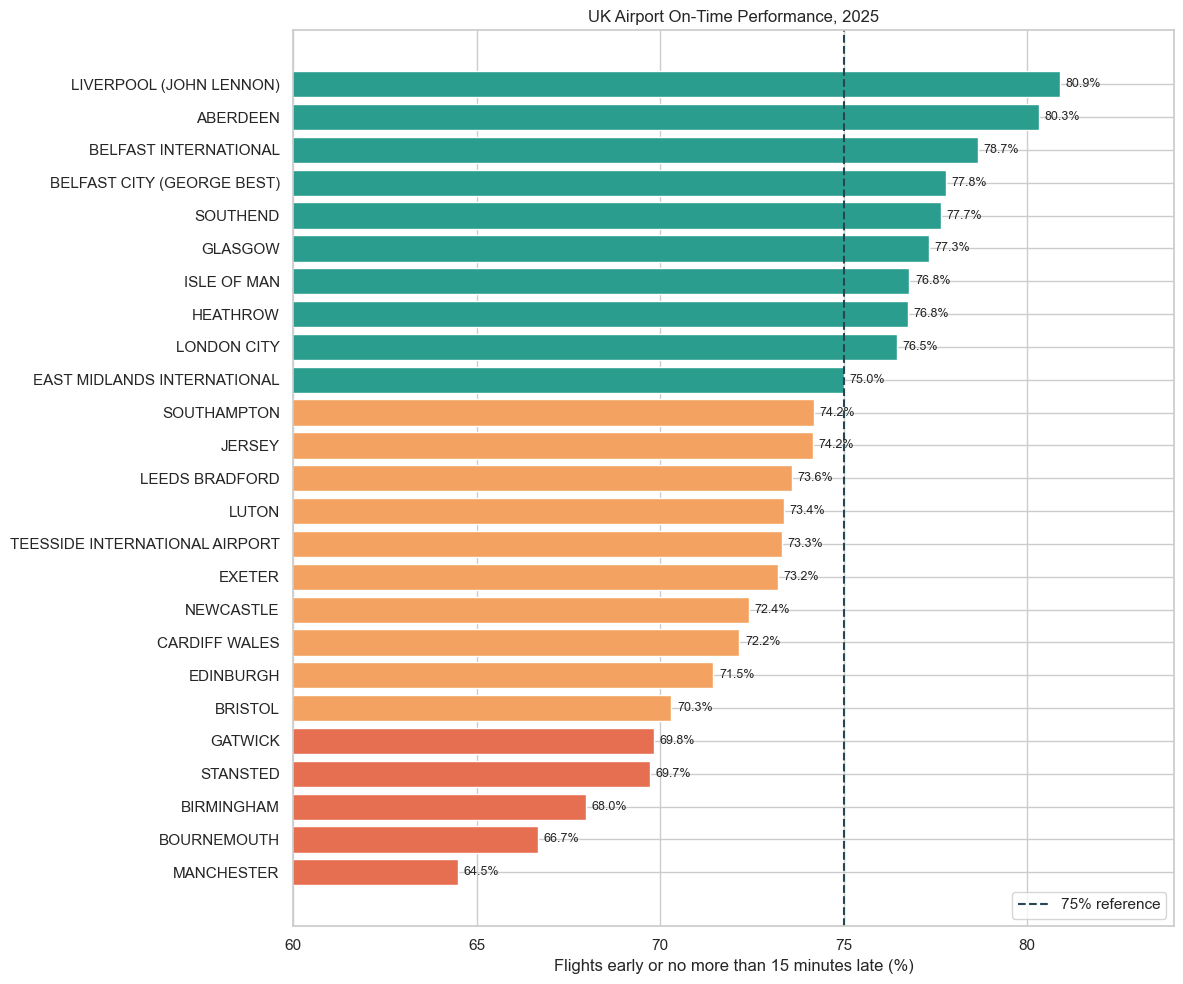

In [19]:
on_time_chart = airport_performance_2025.sort_values(
    "on_time_percent",
    ascending=True,
)

bar_colours = [
    "#2a9d8f" if value >= 75
    else "#f4a261" if value >= 70
    else "#e76f51"
    for value in on_time_chart["on_time_percent"]
]

fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    on_time_chart["airport_name"],
    on_time_chart["on_time_percent"],
    color=bar_colours,
)

ax.axvline(
    75,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label="75% reference",
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in on_time_chart["on_time_percent"]
    ],
    padding=4,
    fontsize=9,
)

ax.set_title("UK Airport On-Time Performance, 2025")
ax.set_xlabel("Flights early or no more than 15 minutes late (%)")
ax.set_ylabel("")
ax.set_xlim(60, 84)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 9. Long-term UK punctuality trend

This section aggregates airport results to show how punctuality changed from
2015 to 2025. Airport-month observations are weighted by matched flights, so
larger operational volumes have a proportionately greater influence on the
national results.

In [20]:
annual_punctuality = (
    punctuality
    .groupby(punctuality["period_date"].dt.year)
    .apply(
        lambda group: pd.Series(
            {
                "flights_matched": group["flights_matched"].sum(),
                "on_time_percent": weighted_average(
                    group, "on_time_percent"
                ),
                "average_delay_minutes": weighted_average(
                    group, "average_delay_minutes"
                ),
                "over_30_minutes_late_percent": weighted_average(
                    group, "over_30_minutes_late_percent"
                ),
                "over_60_minutes_late_percent": weighted_average(
                    group, "over_60_minutes_late_percent"
                ),
                "flights_cancelled": group["flights_cancelled"].sum(
                    min_count=1
                ),
                "flights_unmatched": group["flights_unmatched"].sum(),
            }
        ),
        include_groups=False,
    )
    .reset_index(names="year")
)

annual_punctuality["cancelled_percent"] = (
    100
    * annual_punctuality["flights_cancelled"]
    / (
        annual_punctuality["flights_matched"]
        + annual_punctuality["flights_unmatched"]
        + annual_punctuality["flights_cancelled"]
    )
)

display(
    annual_punctuality.round(
        {
            "on_time_percent": 2,
            "average_delay_minutes": 2,
            "over_30_minutes_late_percent": 2,
            "over_60_minutes_late_percent": 2,
            "cancelled_percent": 2,
        }
    )
)

,year,flights_matched,on_time_percent,average_delay_minutes,over_30_minutes_late_percent,over_60_minutes_late_percent,flights_cancelled,flights_unmatched,cancelled_percent
0,2015,1885145.0,76.68,13.21,11.81,4.61,NaN,8031.0,NaN
1,2016,2000383.0,73.39,15.26,14.06,5.69,NaN,3047.0,NaN
2,2017,2057297.0,73.01,15.11,13.99,5.41,NaN,872.0,NaN
3,2018,2030529.0,72.48,15.83,14.65,6.14,30510.0,12401.0,1.47
4,2019,2006151.0,74.95,14.01,13.10,5.16,18021.0,50386.0,0.87
5,2020,659468.0,83.60,8.46,6.88,2.86,24994.0,151.0,3.65
6,2021,619119.0,83.49,8.83,7.66,2.89,7592.0,1283.0,1.21
7,2022,1529783.0,62.53,22.38,22.13,9.89,24148.0,120.0,1.55
8,2023,1790515.0,63.73,20.80,20.48,8.64,32108.0,207.0,1.76
9,2024,1879260.0,66.94,18.69,18.35,7.59,27160.0,407.0,1.42


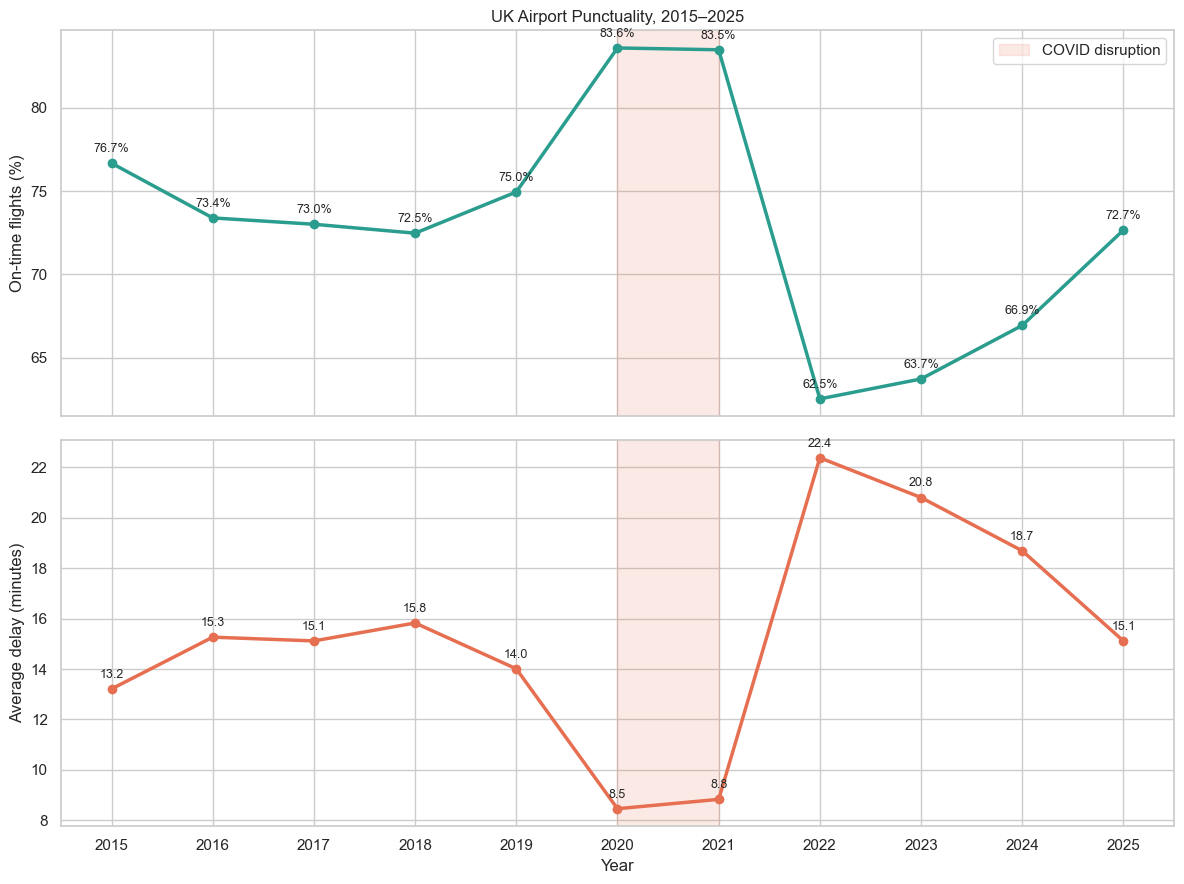

In [21]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True,
)

# On-time performance
axes[0].plot(
    annual_punctuality["year"],
    annual_punctuality["on_time_percent"],
    marker="o",
    linewidth=2.5,
    color="#2a9d8f",
)

axes[0].axvspan(
    2020,
    2021,
    color="#e76f51",
    alpha=0.15,
    label="COVID disruption",
)

for _, row in annual_punctuality.iterrows():
    axes[0].annotate(
        f"{row['on_time_percent']:.1f}%",
        (row["year"], row["on_time_percent"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

axes[0].set_title("UK Airport Punctuality, 2015–2025")
axes[0].set_ylabel("On-time flights (%)")
axes[0].legend()

# Average delay
axes[1].plot(
    annual_punctuality["year"],
    annual_punctuality["average_delay_minutes"],
    marker="o",
    linewidth=2.5,
    color="#e76f51",
)

axes[1].axvspan(
    2020,
    2021,
    color="#e76f51",
    alpha=0.15,
)

for _, row in annual_punctuality.iterrows():
    axes[1].annotate(
        f"{row['average_delay_minutes']:.1f}",
        (row["year"], row["average_delay_minutes"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average delay (minutes)")
axes[1].set_xticks(annual_punctuality["year"])

plt.tight_layout()
plt.show()

### Interpretation

Punctuality improved sharply during 2020 and 2021, when pandemic-related travel
restrictions substantially reduced flight volumes and congestion. These years
should therefore not be interpreted as evidence of a normal operational
improvement.

The reopening period produced the opposite effect. In 2022, on-time performance
fell to 62.5% and average delay rose to 22.4 minutes, the weakest results in the
series. This suggests that operational capacity struggled to adjust to the rapid
return of passenger demand.

Performance subsequently improved each year. By 2025, 72.7% of flights were on
time and average delay had fallen to 15.1 minutes. Nevertheless, punctuality had
not fully returned to its 2019 level of 75.0% on time and 14.0 minutes of average
delay.

## 10. Seasonal punctuality pattern

This section examines whether punctuality varies systematically by month.
The exceptional disruption and recovery years from 2020 to 2022 are excluded,
so the calculation better represents normal operating conditions.

Results are weighted by matched flights across 2015–2019 and 2023–2025.

In [22]:
normal_period = punctuality[
    ~punctuality["period_date"].dt.year.isin([2020, 2021, 2022])
].copy()

normal_period["month_number"] = normal_period["period_date"].dt.month

monthly_punctuality = (
    normal_period
    .groupby("month_number")
    .apply(
        lambda group: pd.Series(
            {
                "flights_matched": group["flights_matched"].sum(),
                "on_time_percent": weighted_average(
                    group, "on_time_percent"
                ),
                "average_delay_minutes": weighted_average(
                    group, "average_delay_minutes"
                ),
                "over_30_minutes_late_percent": weighted_average(
                    group, "over_30_minutes_late_percent"
                ),
                "over_60_minutes_late_percent": weighted_average(
                    group, "over_60_minutes_late_percent"
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

monthly_punctuality["month_name"] = pd.to_datetime(
    monthly_punctuality["month_number"],
    format="%m",
).dt.month_name()

monthly_punctuality = monthly_punctuality[
    [
        "month_number",
        "month_name",
        "flights_matched",
        "on_time_percent",
        "average_delay_minutes",
        "over_30_minutes_late_percent",
        "over_60_minutes_late_percent",
    ]
]

display(
    monthly_punctuality.round(
        {
            "on_time_percent": 2,
            "average_delay_minutes": 2,
            "over_30_minutes_late_percent": 2,
            "over_60_minutes_late_percent": 2,
        }
    )
)

,month_number,month_name,flights_matched,on_time_percent,average_delay_minutes,over_30_minutes_late_percent,over_60_minutes_late_percent
0,1,January,1081107.0,76.85,13.32,11.94,4.88
1,2,February,1058575.0,78.84,11.79,10.55,4.14
2,3,March,1202288.0,76.22,13.53,12.22,5.06
3,4,April,1292005.0,76.85,12.85,11.72,4.40
4,5,May,1414970.0,73.43,14.70,13.64,5.28
5,6,June,1437211.0,65.81,19.49,19.19,8.05
6,7,July,1491184.0,62.67,21.62,21.52,9.14
7,8,August,1501450.0,66.91,19.03,18.25,7.46
8,9,September,1433069.0,67.05,18.39,18.02,7.22
9,10,October,1387536.0,73.68,14.39,13.37,5.11


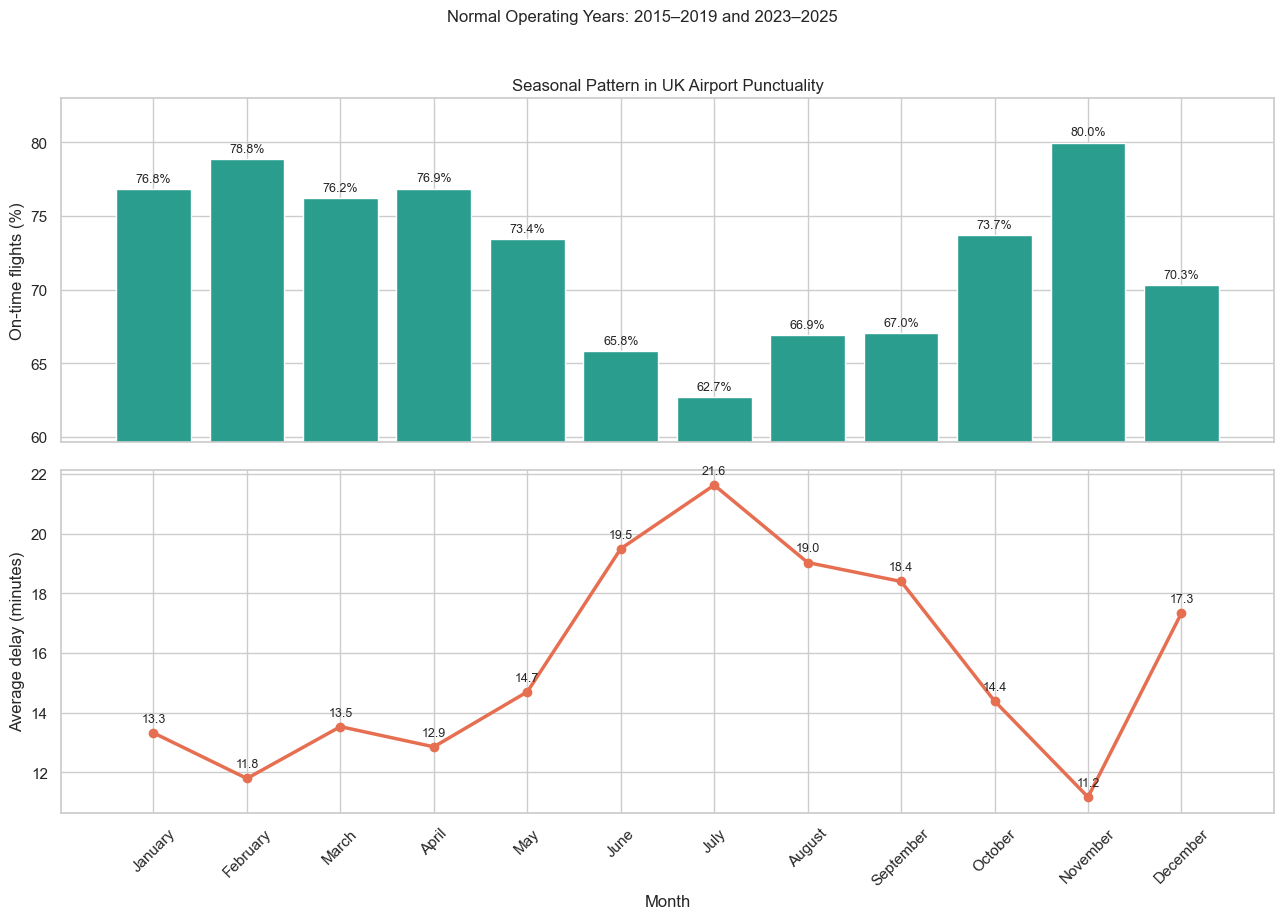

In [23]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    sharex=True,
)

# On-time percentage
bars = axes[0].bar(
    monthly_punctuality["month_name"],
    monthly_punctuality["on_time_percent"],
    color="#2a9d8f",
)

axes[0].bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in monthly_punctuality["on_time_percent"]
    ],
    padding=3,
    fontsize=9,
)

axes[0].set_title(
    "Seasonal Pattern in UK Airport Punctuality"
)
axes[0].set_ylabel("On-time flights (%)")
axes[0].set_ylim(
    monthly_punctuality["on_time_percent"].min() - 3,
    monthly_punctuality["on_time_percent"].max() + 3,
)

# Average delay
axes[1].plot(
    monthly_punctuality["month_name"],
    monthly_punctuality["average_delay_minutes"],
    marker="o",
    linewidth=2.5,
    color="#e76f51",
)

for _, row in monthly_punctuality.iterrows():
    axes[1].annotate(
        f"{row['average_delay_minutes']:.1f}",
        (
            row["month_name"],
            row["average_delay_minutes"],
        ),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

axes[1].set_ylabel("Average delay (minutes)")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle(
    "Normal Operating Years: 2015–2019 and 2023–2025",
    y=1.02,
    fontsize=12,
)

plt.tight_layout()
plt.show()

### Interpretation

UK airport punctuality has a strong seasonal pattern. Performance deteriorates
during the busy summer period, with July recording the lowest on-time rate
(62.7%) and the highest average delay (21.6 minutes). June, August and September
also show relatively weak results.

Punctuality improves substantially during the autumn. November records the
strongest performance, with 80.0% of flights on time and an average delay of
11.2 minutes. Performance then deteriorates again in December, potentially
reflecting winter weather, holiday demand and Christmas-period operational
pressures.

The pattern suggests that higher seasonal demand is associated with increased
pressure on airport and airline capacity.

## 11. Flight cancellation trend

Cancellation data is available from 2018 onwards because the earlier CAA schema
did not include a separate cancellation measure. The annual cancellation rate
uses matched, unmatched and cancelled flights as its denominator.

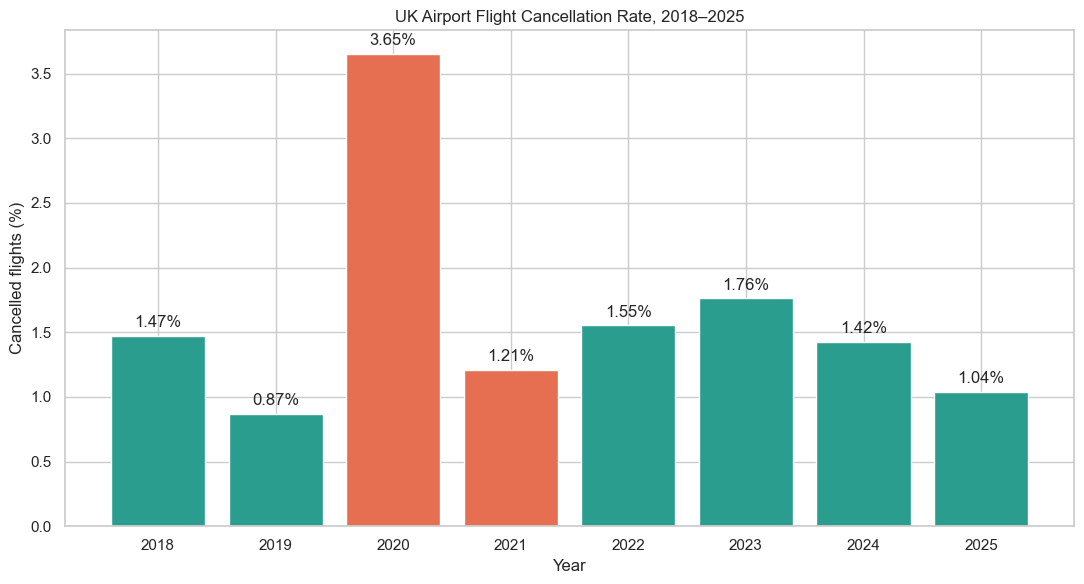

In [24]:
cancellation_trend = annual_punctuality[
    annual_punctuality["cancelled_percent"].notna()
].copy()

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    cancellation_trend["year"],
    cancellation_trend["cancelled_percent"],
    color=[
        "#e76f51" if year in [2020, 2021]
        else "#2a9d8f"
        for year in cancellation_trend["year"]
    ],
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in cancellation_trend["cancelled_percent"]
    ],
    padding=4,
)

ax.set_title("UK Airport Flight Cancellation Rate, 2018–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Cancelled flights (%)")
ax.set_xticks(cancellation_trend["year"])

plt.tight_layout()
plt.show()

## 12. Relationship between passenger demand and punctuality

This section combines the passenger-demand and punctuality datasets to examine
whether busier months tend to experience weaker operational performance.

The analysis uses monthly UK passenger totals as a measure of system demand and
flight-weighted national punctuality measures. The exceptional years from 2020
to 2022 are excluded from the correlation analysis.

In [25]:
passenger_path = (
    project_root / "data" / "interim"
    / "caa_monthly_airport_passengers_2015_2025.csv"
)

passengers = pd.read_csv(
    passenger_path,
    parse_dates=["period_date"],
)

monthly_demand = (
    passengers
    .groupby("period_date", as_index=False)
    .agg(
        terminal_passengers=(
            "terminal_passengers",
            "sum",
        )
    )
)

monthly_punctuality_national = (
    punctuality
    .groupby("period_date")
    .apply(
        lambda group: pd.Series(
            {
                "flights_matched": group["flights_matched"].sum(),
                "on_time_percent": weighted_average(
                    group, "on_time_percent"
                ),
                "average_delay_minutes": weighted_average(
                    group, "average_delay_minutes"
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

demand_punctuality = monthly_demand.merge(
    monthly_punctuality_national,
    on="period_date",
    how="inner",
)

demand_punctuality["year"] = (
    demand_punctuality["period_date"].dt.year
)

normal_demand_punctuality = demand_punctuality[
    ~demand_punctuality["year"].isin([2020, 2021, 2022])
].copy()

correlations = (
    normal_demand_punctuality[
        [
            "terminal_passengers",
            "on_time_percent",
            "average_delay_minutes",
        ]
    ]
    .corr()
    .loc[
        "terminal_passengers",
        ["on_time_percent", "average_delay_minutes"],
    ]
)

print("Merged months:", len(demand_punctuality))
print(
    "Normal-operation months used:",
    len(normal_demand_punctuality),
)
print("\nCorrelation with passenger demand:")
display(correlations.to_frame("correlation").round(3))

Merged months: 132
Normal-operation months used: 96

Correlation with passenger demand:


,correlation
on_time_percent,-0.635
average_delay_minutes,0.585


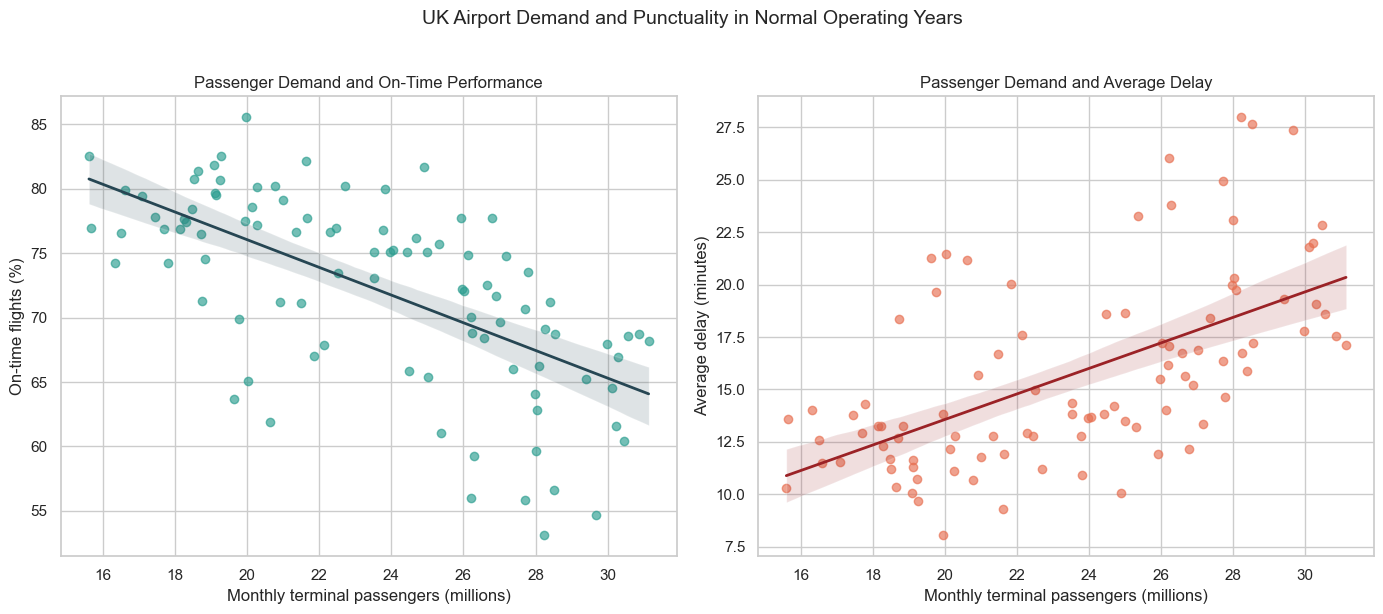

In [26]:
plot_data = normal_demand_punctuality.copy()

plot_data["passengers_millions"] = (
    plot_data["terminal_passengers"] / 1_000_000
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

sns.regplot(
    data=plot_data,
    x="passengers_millions",
    y="on_time_percent",
    scatter_kws={
        "alpha": 0.65,
        "color": "#2a9d8f",
    },
    line_kws={
        "color": "#264653",
        "linewidth": 2,
    },
    ax=axes[0],
)

axes[0].set_title(
    "Passenger Demand and On-Time Performance"
)
axes[0].set_xlabel("Monthly terminal passengers (millions)")
axes[0].set_ylabel("On-time flights (%)")

sns.regplot(
    data=plot_data,
    x="passengers_millions",
    y="average_delay_minutes",
    scatter_kws={
        "alpha": 0.65,
        "color": "#e76f51",
    },
    line_kws={
        "color": "#9b2226",
        "linewidth": 2,
    },
    ax=axes[1],
)

axes[1].set_title(
    "Passenger Demand and Average Delay"
)
axes[1].set_xlabel("Monthly terminal passengers (millions)")
axes[1].set_ylabel("Average delay (minutes)")

fig.suptitle(
    "UK Airport Demand and Punctuality in Normal Operating Years",
    fontsize=14,
    y=1.02,
)

plt.tight_layout()
plt.show()

## 13. Key findings and limitations

### Key findings

- The clean punctuality dataset contains 3,354 airport-month records covering
  27 airports from January 2015 to December 2025. Twenty-two airports have a
  complete 132-month history.
- In 2025, Liverpool (John Lennon) recorded the highest weighted on-time rate
  at 80.9%, followed by Aberdeen at 80.3%. Manchester recorded the lowest rate
  at 64.5% and the highest average delay at 19.8 minutes.
- Punctuality appeared unusually strong during 2020 and 2021 because travel
  restrictions greatly reduced flight volumes and congestion.
- The 2022 reopening period produced the weakest annual result: 62.5% of flights
  were on time and average delay reached 22.4 minutes.
- Performance improved from 2023 to 2025, although the 2025 result remained
  slightly weaker than the 2019 pre-pandemic benchmark.
- Punctuality has a strong seasonal pattern. July recorded the weakest normal-
  period performance, while November recorded the strongest.
- The cancellation rate peaked at 3.65% in 2020 and declined to 1.04% by 2025.
- During normal operating years, passenger demand had a correlation of -0.635
  with on-time performance and +0.585 with average delay. Busier months were
  therefore generally associated with weaker punctuality.

### Limitations

- Correlation describes association and does not prove that passenger demand
  directly causes delays.
- Other important factors—including weather, air-traffic restrictions,
  industrial action, airline scheduling and airport capacity—are not included.
- CAA punctuality data covers a defined group of reporting airports rather than
  every UK airport.
- The CAA schema changed in 2018. Common punctuality measures were harmonised,
  but explicit cancellation data is unavailable before 2018.
- Annual and monthly national measures are weighted by matched flights, so
  larger airports have a greater influence on the results.

In [27]:
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

airport_output_path = (
    processed_dir
    / "punctuality_airport_performance_2025.csv"
)

annual_output_path = (
    processed_dir
    / "punctuality_annual_summary_2015_2025.csv"
)

relationship_output_path = (
    processed_dir
    / "monthly_demand_and_punctuality_2015_2025.csv"
)

airport_performance_2025.to_csv(
    airport_output_path,
    index=False,
)

annual_punctuality.to_csv(
    annual_output_path,
    index=False,
)

demand_punctuality.to_csv(
    relationship_output_path,
    index=False,
)

validation_checks = {
    "rows": len(punctuality),
    "airports": punctuality["airport_name"].nunique(),
    "months": punctuality["period_date"].nunique(),
    "complete_history_airports": int(
        punctuality.loc[
            punctuality["complete_history"],
            "airport_name",
        ].nunique()
    ),
    "duplicate_airport_months": int(
        punctuality.duplicated(
            ["airport_name", "period_date"]
        ).sum()
    ),
    "missing_average_delay": int(
        punctuality["average_delay_minutes"].isna().sum()
    ),
    "missing_on_time_percentage": int(
        punctuality["on_time_percent"].isna().sum()
    ),
    "invalid_on_time_percentage": int(
        (
            ~punctuality["on_time_percent"].between(0, 100)
        ).sum()
    ),
    "negative_matched_flights": int(
        (punctuality["flights_matched"] < 0).sum()
    ),
}

for check, value in validation_checks.items():
    print(f"{check}: {value}")

assert validation_checks["months"] == 132
assert validation_checks["duplicate_airport_months"] == 0
assert validation_checks["missing_average_delay"] == 0
assert validation_checks["missing_on_time_percentage"] == 0
assert validation_checks["invalid_on_time_percentage"] == 0
assert validation_checks["negative_matched_flights"] == 0

print("\nAll final validation checks passed.")

print("\nExported files:")
print(airport_output_path)
print(annual_output_path)
print(relationship_output_path)

rows: 3354
airports: 27
months: 132
complete_history_airports: 22
duplicate_airport_months: 0
missing_average_delay: 0
missing_on_time_percentage: 0
invalid_on_time_percentage: 0
negative_matched_flights: 0

All final validation checks passed.

Exported files:
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/punctuality_airport_performance_2025.csv
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/punctuality_annual_summary_2015_2025.csv
/Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/monthly_demand_and_punctuality_2015_2025.csv
